# Cross-species integration via orthologs

Single-cell datasets from **different species** live in different gene-symbol
spaces, so they cannot be integrated directly. omicverse bridges them with
**one-to-one orthologs** from Ensembl BioMart, then reuses its existing
integration backends to align the datasets *across species*
([issue #856](https://github.com/omicverse/omicverse/issues/856)).

Everything is in `ov.single`:

1. `get_orthologs(source, target)` — homologous-gene table from Ensembl BioMart.
2. `map_var_to_orthologs(adata, source, target)` — transfer a dataset onto the
   other species' gene symbols.
3. `cross_species_integrate([...], [...])` — align to a reference species, keep
   the shared orthologs, and integrate.

We use the **SATURN** frog + zebrafish embryogenesis pair — two *distant*
vertebrates (~430 Myr diverged). At that distance a linear correction (Harmony)
is not enough, so we integrate with **scVI**. As we'll see, one-to-one orthologs
carry enough signal to align the major **germ layers** across species, but *fine*
cell-type homology at this distance is where protein-embedding methods (SATURN)
go further — we quantify exactly that below.

In [1]:
import omicverse as ov
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier

ov.plot_set()

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


🔬 Starting plot initialization...
🧬 Detecting GPU devices…


✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1. Load the SATURN frog + zebrafish data

`ov.datasets.saturn_frog_zebrafish()` returns two AnnData objects with **raw
counts**, species-native gene symbols, and SATURN's harmonized `cell_type` /
`germ_layer` labels — small sparse conversions of SATURN's official sources
(Briggs et al. 2018 *Xenopus*; Wagner et al. 2018 zebrafish).

In [2]:
frog, zebrafish = ov.datasets.saturn_frog_zebrafish()
shared = sorted(set(frog.obs['cell_type']) & set(zebrafish.obs['cell_type']))
print('frog     :', frog.shape)
print('zebrafish:', zebrafish.shape)
print(f'shared harmonized cell types: {len(shared)}')

🔍 Downloading data to ./data/frog_saturn.h5ad


Downloading: |          | 0.00/? [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/47.1M [00:00<?, ?B/s]

Downloading:  10%|▉         | 4.56M/47.1M [00:00<00:00, 45.6MB/s]

Downloading:  18%|█▊        | 8.40M/47.1M [00:00<00:03, 12.8MB/s]

...

Downloading:  90%|█████████ | 74.2M/82.4M [00:02<00:00, 31.8MB/s]

Downloading:  98%|█████████▊| 81.1M/82.4M [00:02<00:00, 39.1MB/s]

Downloading: 100%|█████████▉| 82.4M/82.4M [00:02<00:00, 31.7MB/s]

✅ Download completed


frog     : (4837, 22382)
zebrafish: (5983, 16950)
shared harmonized cell types: 28


## 2. Homologous-gene transfer (Ensembl BioMart)

In [3]:
ortho = ov.single.get_orthologs('zebrafish', 'frog')   # danio -> xenopus
print('one-to-one zebrafish->frog orthologs:', len(ortho))
ortho.head()

one-to-one zebrafish->frog orthologs: 9253


,source_symbol,target_symbol,orthology_type
0,tmem177,tmem177,ortholog_one2one
1,ostc,ostc,ortholog_one2one
2,rab9b,rab9b,ortholog_one2one
3,slc39a9,slc39a9,ortholog_one2one
4,gpkow,gpkow,ortholog_one2one


## 3. Cross-species integration with scVI

`cross_species_integrate` maps both datasets onto the reference species'
one-to-one orthologs, keeps the shared genes, adds a `species` batch label, and
runs the backend. For these distant species we use **scVI** (raw counts, NB
likelihood).

In [4]:
adata = ov.single.cross_species_integrate(
    [zebrafish, frog], ['zebrafish', 'frog'],
    ref_species='zebrafish', method='scVI',
    n_top_genes=2000, n_pcs=30)
adata.uns['cross_species']

...Begin using scVI to correct batch effect


INFO: GPU available: True (cuda), used: True


INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True


INFO: TPU available: False, using: 0 TPU cores


INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores


...

Training:   0%|          | 0/400 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=400` reached.


INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=400` reached.



╭─ SUMMARY: batch_correction ────────────────────────────────────────╮
│  Duration: 179.568s                                                │
│  Shape:    10,820 x 2,000 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ _scvi_batch (int)                                    │
│           │ ✚ _scvi_labels (int)                                   │
│                                                                    │
│  ● UNS    │ ✚ REFERENCE_MANU                                       │
│           │ ✚ _ov_provenance                                       │
│           │ ✚ _scvi_manager_uuid                                   │
│           │ ✚ _scvi_uuid                                           │
│                                                                    │
│  ● 

{'ref_species': 'zebrafish',
 'species': ['zebrafish', 'frog'],
 'n_common_orthologs': 5603,
 'method': 'scVI',
 'orthology_type': 'one2one'}

## 4. Visualise

Embed on the scVI representation and colour by species and by germ layer.

INFO:omicverse.pp._neighbors:computing neighbors


🖥️ Using Scanpy CPU to calculate neighbors...

🔍 K-Nearest Neighbors Graph Construction:
   Mode: cpu
   Neighbors: 15
   Method: umap
   Metric: euclidean
   Representation: X_scVI
   🔍 Computing neighbor distances...


   🔍 Computing connectivity matrix...
   💡 Using UMAP-style connectivity


   ✓ Graph is fully connected

✅ KNN Graph Construction Completed Successfully!
   ✓ Processed: 10,820 cells with 15 neighbors each
   ✓ Results added to AnnData object:
     • 'neighbors': Neighbors metadata (adata.uns)
     • 'distances': Distance matrix (adata.obsp)
     • 'connectivities': Connectivity matrix (adata.obsp)

╭─ SUMMARY: neighbors ───────────────────────────────────────────────╮
│  Duration: 23.661s                                                 │
│  Shape:    10,820 x 2,000 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ neighbors                                            │
│           │ └─ params: {'n_neighbors': 15, 'method': 'umap', 'random_s...│
│                                                                    │
│  ● OBSP   │ ✚ connectivi


✅ UMAP Dimensionality Reduction Completed Successfully!
   ✓ Embedding shape: 10,820 cells × 2 dimensions
   ✓ Results added to AnnData object:
     • 'X_umap': UMAP coordinates (adata.obsm)
     • 'umap': UMAP parameters (adata.uns)
✅ UMAP completed successfully.

╭─ SUMMARY: umap ────────────────────────────────────────────────────╮
│  Duration: 1.2457s                                                 │
│  Shape:    10,820 x 2,000 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ umap                                                 │
│           │ └─ params: {'a': np.float64(0.5830300203414425), 'b': np.f...│
│                                                                    │
│  ● OBSM   │ ✚ X_umap (array, 10820x2)                              │
│                

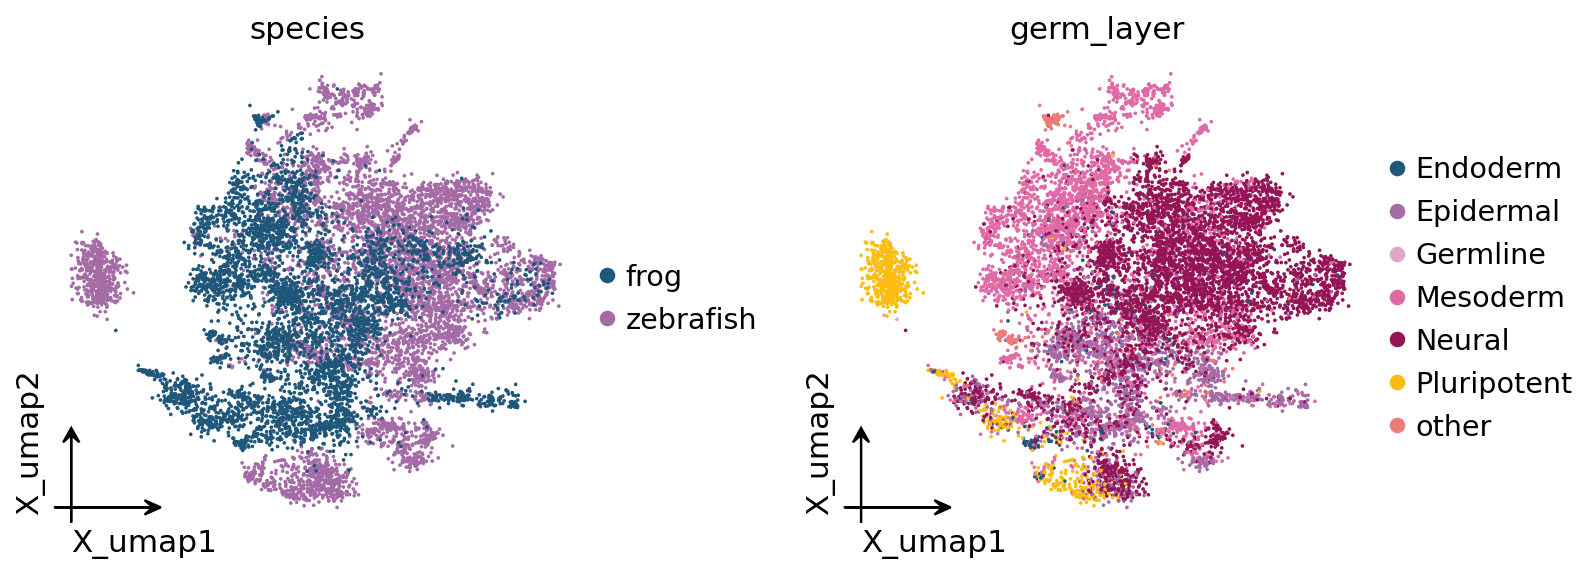

In [5]:
ov.pp.neighbors(adata, use_rep='X_scVI', n_neighbors=15)
ov.pp.umap(adata)
ov.pl.embedding(adata, basis='X_umap', color=['species', 'germ_layer'],
                frameon='small', wspace=0.5)

## 5. Evaluate — cell-type consistency, not just species mixing

A cluster containing both species is **not** proof of good integration: an
over-aggressive method can blend everything and still look "mixed". The honest
test is whether **homologous cell types align across species**. We measure it as
cross-species **label transfer**: train a kNN classifier on *zebrafish* labels in
the embedding, predict the *frog* cells, and compare to their true labels —
before (raw ortholog PCA) vs after scVI, at germ-layer and fine cell-type
resolution.

In [6]:
def xspecies_transfer(rep, label):
    m = adata.obsm[rep]
    sp = adata.obs['species'].values
    y = adata.obs[label].astype(str).values
    shared = (set(y[sp == 'zebrafish']) & set(y[sp == 'frog'])) - {'other'}
    tr = (sp == 'zebrafish') & np.isin(y, list(shared))
    te = (sp == 'frog') & np.isin(y, list(shared))
    knn = KNeighborsClassifier(n_neighbors=15).fit(m[tr], y[tr])
    return (knn.predict(m[te]) == y[te]).mean(), len(shared)

for label in ['germ_layer', 'cell_type']:
    a_pre, n = xspecies_transfer('X_pca', label)
    a_post, _ = xspecies_transfer('X_scVI', label)
    print(f'{label:11s} ({n:2d} classes, chance~{1/n:.2f}):  '
          f'before={a_pre:.2f}  after scVI={a_post:.2f}')

germ_layer  ( 6 classes, chance~0.17):  before=0.54  after scVI=0.64


cell_type   (28 classes, chance~0.04):  before=0.22  after scVI=0.28


## Summary

- `ov.single.get_orthologs` / `map_var_to_orthologs` — homologous-gene transfer
  between any Ensembl species.
- `ov.single.cross_species_integrate` — one-call cross-species integration on the
  shared one-to-one orthologs, reusing omicverse's `batch_correction` backends.

**What the ortholog route buys you — and where it stops.** For frog↔zebrafish
(~430 Myr), scVI mixes the two species and aligns the major **germ layers**
across them (label transfer ≈ 3× chance), but *fine* cell-type homology is only
weakly recovered — one-to-one orthologs simply lose that resolution at large
evolutionary distance.

| Species distance | Example | Ortholog route | For fine cell types |
|---|---|---|---|
| Close | human ↔ mouse | `method='harmony'` / `'scVI'` — aligns cell types | ✓ |
| Distant | frog ↔ zebrafish | germ-layer alignment (this tutorial) | use **SAMap** / **SATURN** |

**SAMap** (BLAST homology graph) and **SATURN** (protein language-model
embeddings) go beyond one-to-one orthologs and are the tools of choice when fine
cross-species cell-type correspondence at large distances is the goal.

## Beyond one-to-one orthologs: SAMap & SATURN

The ortholog route above is fast but only uses **one-to-one** orthologs, which
lose resolution at large evolutionary distances. omicverse also vendors the two
homology-aware methods from issue #856 (under `omicverse.external`, exposed in
`ov.single`):

- **`samap_integrate`** — [SAMap](https://elifesciences.org/articles/66747):
  builds a **reciprocal-BLAST gene-homology graph** (many-to-many homology) and
  runs the Self-Assembling Manifold.
- **`saturn_integrate`** — [SATURN](https://www.nature.com/articles/s41592-024-02191-z):
  learns **"macrogenes" from ESM2 protein language-model embeddings** to map
  species into a shared space.

Both need protein data (BLAST proteomes / ESM embeddings), not just counts, so
they are heavier than the ortholog route — the snippets below show the API.

### SAMap

`build_blast_maps` defaults to **DIAMOND** when available (~40-50× faster than
NCBI `blastp` — reciprocal frog↔zebrafish maps in ~65 s vs ~1 h — with both
directions run concurrently), falling back to `blastp` otherwise.

In [ ]:
# needs Ensembl peptide FASTAs + DIAMOND/BLAST on PATH — heavy, not run here
from omicverse.external.samap._run import build_blast_maps

build_blast_maps(
    {'zf': 'Danio_rerio.pep.fa', 'fr': 'Xenopus_tropicalis.pep.fa'},
    out_dir='maps', engine='diamond', threads=16)          # DIAMOND, both directions

adata_samap = ov.single.samap_integrate(
    [zebrafish, frog], ids=['zf', 'fr'], ensembl_species=['zebrafish', 'frog'],
    proteomes={'zf': 'Danio_rerio.pep.fa', 'fr': 'Xenopus_tropicalis.pep.fa'},
    blast_maps='maps')
# adata_samap.obsm['X_umap'] is SAMap's joint cross-species embedding

### SATURN

SATURN needs a precomputed **protein embedding** per species — a
`torch`-saved dict `{gene_symbol: ESM2_vector}` (generated by running ESM2 over
each proteome).

In [ ]:
# needs ESM2 protein embeddings per species — heavy (GPU), not run here
adata_saturn = ov.single.saturn_integrate(
    [zebrafish, frog], ['zebrafish', 'frog'],
    embedding_paths={'zebrafish': 'zebrafish_esm.pt', 'frog': 'frog_esm.pt'},
    in_label_col='cell_type', n_macrogenes=2000, epochs=(50, 50), device='cuda')
# adata_saturn.obsm['X_saturn'] is SATURN's shared macrogene embedding

### Which method, and how well do they align cell types?

Species *mixing* alone is misleading, so we score **cross-species cell-type
label transfer** (train a kNN on zebrafish labels in each method's embedding,
predict the frog cells). On this frog↔zebrafish pair (~430 Myr):

| Method | germ-layer (6) | cell type (28) | needs |
|---|---|---|---|
| `cross_species_integrate` (orthologs + scVI) | 0.64 | 0.28 | BioMart only |
| `samap_integrate` (SAMap) | 0.70 | 0.43 | + proteomes / BLAST |
| `saturn_integrate` (SATURN) | **0.86** | **0.63** | + ESM2 embeddings |

*(chance ≈ 0.17 / 0.04.)* The ordering is the expected one: the deeper the
homology signal a method uses (one-to-one orthologs → BLAST graph → protein
embeddings), the better fine cell types align across distant species — at
increasing input/compute cost. Use the ortholog route for close species or a
quick first pass, and SAMap / SATURN when fine cross-species cell-type
correspondence at large distance is the goal.